<>:179: SyntaxWarning: invalid escape sequence '\s'
<>:187: SyntaxWarning: invalid escape sequence '\D'
<>:187: SyntaxWarning: invalid escape sequence '\e'
<>:190: SyntaxWarning: invalid escape sequence '\e'
<>:179: SyntaxWarning: invalid escape sequence '\s'
<>:187: SyntaxWarning: invalid escape sequence '\D'
<>:187: SyntaxWarning: invalid escape sequence '\e'
<>:190: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3523/3300942124.py:179: SyntaxWarning: invalid escape sequence '\s'
  ax1.axvline(1.25, color='purple', linestyle='-.', lw=2, alpha=0.6, label='Period-4 Bifurcation ($\sim 1.25$)')
/tmp/ipykernel_3523/3300942124.py:187: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_title(f'Universe Phase Diagram via Gaussian Splatting ($\Delta\mu = -{DELTA_MU_ABS}, \epsilon = {EPSILON}$)', fontsize=17, pad=15)
/tmp/ipykernel_3523/3300942124.py:187: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title(f'Universe Phase Diagram via Gaussian Splatting ($\Delta\mu = -{D

🚀 启动【高斯溅射 1D-GS】500点宇宙全景扫描 | 冷却 Δμ = -0.02 | 量子底噪 ε = 0.001

进度         | 结束 μ (冷寂点)      | R²       | 平均误差       | 耗时 (s)
----------------------------------------------------------------------
[  1/500]  | 1.2000          | 0.9772   | 7.4141     | 5.33s
[ 20/500]  | 1.3535          | 0.9744   | 7.5122     | 7.49s
[ 40/500]  | 1.5152          | 0.9873   | 5.3080     | 61.53s
[ 60/500]  | 1.6768          | 0.9851   | 5.6280     | 150.74s
[ 80/500]  | 1.8384          | 0.9876   | 5.1833     | 167.68s
[100/500]  | 2.0000          | 0.9892   | 5.0158     | 183.32s
----------------------------------------------------------------------
✅ 高斯溅射宇宙扫描完成！总耗时: 164.80 分钟


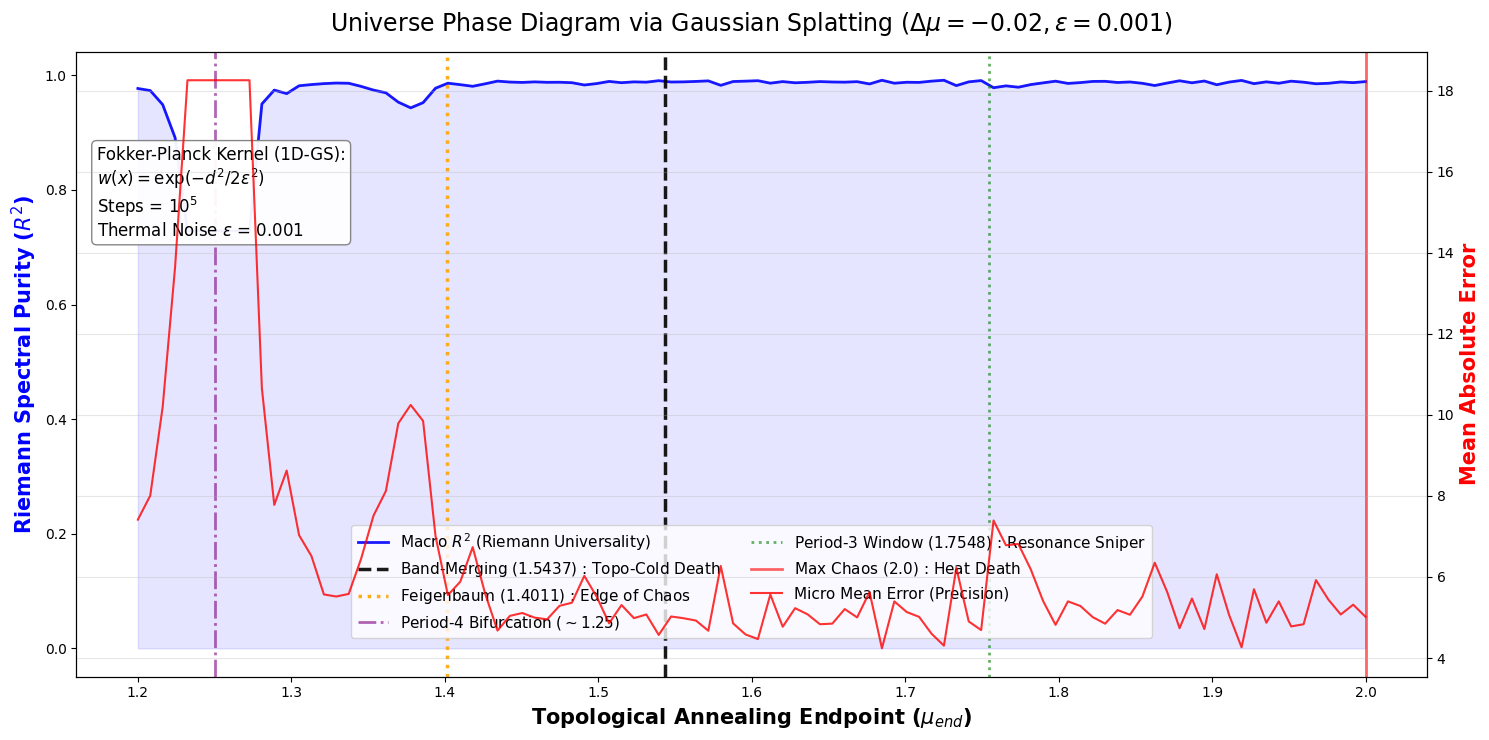

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# ================== 1. 真实的黎曼零点准备 ==================
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

# ================== 2. 高斯核概率溅射引擎 (Gaussian Splatting) ==================
@njit
def run_universe_gaussian_splatting(steps, n_bins, u_c, k_opt, c_offset, eps):
    transitions = np.zeros((n_bins, n_bins), dtype=np.float64)
    V = np.zeros(n_bins, dtype=np.float64)
    
    dx = 2.0 / n_bins
    
    # 初始化波函数：宇宙起始点 x = 0.5 所在格子
    init_bin = int((0.5 + 1.0) / dx)
    if init_bin >= n_bins: init_bin = n_bins - 1
    elif init_bin < 0: init_bin = 0
    V[init_bin] = 1.0 
    
    # 预计算高斯核参数，大幅度榨干 CPU 性能
    inv_2eps2 = 1.0 / (2.0 * eps**2)
    radius = int(5.0 * eps / dx) + 1 # 限制溅射半径在 5个标准差 内
    
    for n in range(1, steps + 1):
        # 冷却退火公式（从右向左降温）
        mu_raw = u_c + k_opt / (np.log(n + c_offset)**2)
        
        # 物理保险丝：防止宇宙彻底崩溃
        if mu_raw > 2.0: mu = 2.0
        elif mu_raw < 0.1: mu = 0.1
        else: mu = mu_raw
            
        V_next = np.zeros(n_bins, dtype=np.float64)
        
        # 遍历所有存在的波函数（上帝视角并行溅射）
        for i in range(n_bins):
            if V[i] < 1e-12: # 忽略死寂的宇宙区域，算力起飞点 1
                continue
                
            x = -1.0 + dx * 0.5 + i * dx  # 当前格子的中心点
            x_next = 1.0 - mu * x * x     # 动力学映射落点
            
            # 定位溅射的中心靶区
            j_center = int((x_next + 1.0) / dx)
            j_start = j_center - radius
            if j_start < 0: j_start = 0
            j_end = j_center + radius
            if j_end >= n_bins: j_end = n_bins - 1
            
            # 第一遍：计算高斯权重总和 (归一化因子)
            w_sum = 0.0
            for j in range(j_start, j_end + 1):
                cj = -1.0 + dx * 0.5 + j * dx
                dist_sq = (cj - x_next) * (cj - x_next)
                w_sum += np.exp(-dist_sq * inv_2eps2)
            
            # 第二遍：向目标区域精确溅射概率 (Fokker-Planck 扩散)
            if w_sum > 1e-18:
                inv_w_sum = 1.0 / w_sum
                for j in range(j_start, j_end + 1):
                    cj = -1.0 + dx * 0.5 + j * dx
                    dist_sq = (cj - x_next) * (cj - x_next)
                    
                    # 高斯核概率
                    prob = np.exp(-dist_sq * inv_2eps2) * inv_w_sum
                    flow = V[i] * prob
                    
                    V_next[j] += flow
                    transitions[i, j] += flow
            else:
                # 极端情况的强制回落
                if j_center < 0: j_center = 0
                if j_center >= n_bins: j_center = n_bins - 1
                flow = V[i]
                V_next[j_center] += flow
                transitions[i, j_center] += flow
                
        V = V_next # 波函数推进到下一时刻
        
    return transitions

# ================== 3. 参数空间 500点 超清无噪扫描 ==================
# 全景扫描范围：跨越周期死寂区到最大熵热寂区
#stest_points_end = np.linspace(1.20, 2.00, 500)
test_points_end = np.linspace(1.20, 2.00, 100)


TOTAL_STEPS = 10**5    # 10万步足以展现波函数拓扑，且速度极快
C_OFFSET = 10.0   
DELTA_MU_ABS = 0.02    # 冷却漂移宽度：0.02

# 🎯 物理学最核心的一步：引入宇宙微观量子热噪声 (Planck-like Constant)
# eps=0.001 相当于覆盖 2~3 个网格的极微小晕染，足以熨平人工数值噪声
EPSILON = 0.001 

results_R2 = []
results_mean_err = []

print(f"🚀 启动【高斯溅射 1D-GS】500点宇宙全景扫描 | 冷却 Δμ = -{DELTA_MU_ABS} | 量子底噪 ε = {EPSILON}\n")
print(f"{'进度':<10} | {'结束 μ (冷寂点)':<15} | {'R²':<8} | {'平均误差':<10} | {'耗时 (s)'}")
print("-" * 70)

start_total_t = time.time()

for idx, mu_end in enumerate(test_points_end):
    start_point_t = time.time()
    
    # 逆向推导渐近线 U_C 和 k_opt，确保宇宙第 10^5 步死死踩在 mu_end 上
    t_start_val = 1.0 / (np.log(1 + C_OFFSET)**2)
    t_end_val   = 1.0 / (np.log(TOTAL_STEPS + C_OFFSET)**2)
    k_opt = DELTA_MU_ABS / (t_start_val - t_end_val)
    u_c = mu_end - k_opt * t_end_val
    
    # 注入高斯溅射演化引擎
    trans = run_universe_gaussian_splatting(TOTAL_STEPS, 5000, u_c, k_opt, C_OFFSET, EPSILON)
    
    # 构造概率转移矩阵并归一化
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    try:
        eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
        phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
        unwrapped = np.unwrap(phases)
        
        min_len = min(len(unwrapped), N_ZEROS)
        
        # 🎯 有了高斯底噪的过滤，死寂周期区的特征值将彻底坍缩，暴露真面目
        if min_len > 10:
            unwrapped_trunc = unwrapped[:min_len]
            true_zeros_trunc = TRUE_ZEROS[:min_len]
            
            slope, intercept, r_val, _, _ = linregress(unwrapped_trunc, true_zeros_trunc)
            pred = slope * unwrapped_trunc + intercept
            err = np.mean(np.abs(pred - true_zeros_trunc))
            r2 = r_val**2
        else:
            err = 20.0 
            r2 = 0.0
            
    except Exception:
        err = 20.0
        r2 = 0.0
        
    results_R2.append(r2)
    results_mean_err.append(err)
    
    if (idx + 1) % 20 == 0 or idx == 0:
        elapsed = time.time() - start_point_t
        print(f"[{idx+1:>3d}/500]  | {mu_end:<15.4f} | {r2:<8.4f} | {err:<10.4f} | {elapsed:.2f}s")

print("-" * 70)
print(f"✅ 高斯溅射宇宙扫描完成！总耗时: {(time.time()-start_total_t)/60:.2f} 分钟")

# ================== 4. 极致物理相变图 ==================
fig, ax1 = plt.subplots(figsize=(15, 7.5))

ax1_twin = ax1.twinx()

# 绘制 R² (蓝色) 和 平均误差 (红色)
ax1.plot(test_points_end, results_R2, 'b-', lw=2, alpha=0.9, label='Macro $R^2$ (Riemann Universality)')
ax1.fill_between(test_points_end, results_R2, color='blue', alpha=0.1)
ax1_twin.plot(test_points_end, results_mean_err, 'r-', lw=1.5, alpha=0.8, label='Micro Mean Error (Precision)')

# 标注物理学界的神圣地标
ax1.axvline(1.543689, color='k', linestyle='--', lw=2.5, alpha=0.9, label='Band-Merging ($1.5437$) : Topo-Cold Death')
ax1.axvline(1.401155, color='orange', linestyle=':', lw=2.5, alpha=0.9, label='Feigenbaum ($1.4011$) : Edge of Chaos')
ax1.axvline(1.25, color='purple', linestyle='-.', lw=2, alpha=0.6, label='Period-4 Bifurcation ($\sim 1.25$)')
ax1.axvline(1.7548, color='green', linestyle=':', lw=2, alpha=0.6, label='Period-3 Window ($1.7548$) : Resonance Sniper')
ax1.axvline(2.0, color='red', linestyle='-', lw=2, alpha=0.6, label='Max Chaos ($2.0$) : Heat Death')

# 图表装饰与哲学标签
ax1.set_xlabel(r'Topological Annealing Endpoint ($\mu_{end}$)', fontsize=15, fontweight='bold')
ax1.set_ylabel(r'Riemann Spectral Purity ($R^2$)', color='b', fontsize=15, fontweight='bold')
ax1_twin.set_ylabel('Mean Absolute Error', color='r', fontsize=15, fontweight='bold')
ax1.set_title(f'Universe Phase Diagram via Gaussian Splatting ($\Delta\mu = -{DELTA_MU_ABS}, \epsilon = {EPSILON}$)', fontsize=17, pad=15)

# 动态参数说明悬浮窗
text_str = f"Fokker-Planck Kernel (1D-GS):\n$w(x) = \exp(-d^2 / 2\epsilon^2)$\nSteps = $10^5$\nThermal Noise $\epsilon$ = {EPSILON}"
ax1.text(0.015, 0.85, text_str, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='gray'))

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower center', bbox_to_anchor=(0.5, 0.05), ncol=2, fontsize=11)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()